# Personalized Content & Product Recommendation System for a Multi-Channel Subscription Business

(same email, same message, same time, to every customer) toward individualized messaging
based on purchase behavior and location — especially now that the business spans both
its core subscription channel and a new retail channel (Target).

This notebook builds an end-to-end prototype of a system that could support that shift:

1. Synthetic customer + transaction data (subscription + retail)
2. Feature engineering (recency, frequency, monetary, channel mix, churn signal)
3. Customer segmentation (KMeans)
4. A supervised model predicting recommendation-response likelihood (XGBoost)
5. A simple contextual bandit simulation that learns which message positioning works best per segment



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
import xgboost as xgb

np.random.seed(42)
pd.set_option('display.max_columns', 20)


## 1. Synthetic data generation

Simulate 8,000 customers with subscription behavior, box customization patterns, and a flag for whether they've also purchased through the new retail (Target) channel.

In [2]:
N = 8000

df = pd.DataFrame({
    'customer_id': range(1, N + 1),
    'tenure_months': np.random.gamma(shape=3, scale=6, size=N).clip(1, 96).round(1),
    'orders_last_90d': np.random.poisson(2.2, N),
    'avg_order_value': np.random.normal(115, 30, N).clip(40, 300).round(2),
    'box_customization_rate': np.random.beta(2, 5, N),          # how often they swap items
    'seafood_pref_share': np.random.beta(2, 6, N),               # share of orders w/ seafood
    'discount_sensitivity': np.random.beta(2, 3, N),             # historical response to discounts
    'retail_channel_flag': np.random.binomial(1, 0.22, N),       # bought via Target too
    'delivery_delays_last_yr': np.random.poisson(0.6, N),
})

# recency: days since last order, correlated inversely with orders_last_90d
df['days_since_last_order'] = (60 / (df['orders_last_90d'] + 0.5) * np.random.uniform(0.7, 1.3, N)).clip(1, 180).round(0)

# churn risk proxy: higher recency + delivery delays + low customization -> higher churn risk
df['churn_risk_score'] = (
    0.4 * (df['days_since_last_order'] / 180) +
    0.3 * (df['delivery_delays_last_yr'] / 5).clip(0, 1) +
    0.3 * (1 - df['box_customization_rate'])
).clip(0, 1)

df.head()


,customer_id,tenure_months,orders_last_90d,avg_order_value,box_customization_rate,seafood_pref_share,discount_sensitivity,retail_channel_flag,delivery_delays_last_yr,days_since_last_order,churn_risk_score
0,1,21.4,3,125.56,0.233289,0.170407,0.744505,0,1,19.0,0.332236
1,2,14.7,4,163.39,0.154351,0.200724,0.358114,0,1,13.0,0.342584
2,3,13.8,3,161.58,0.280469,0.284379,0.448461,0,1,18.0,0.315859
3,4,13.8,7,143.26,0.328926,0.132166,0.326310,0,0,6.0,0.214656
4,5,37.0,4,121.07,0.308868,0.146226,0.685127,0,1,13.0,0.296228


## 2. Feature engineering

Build the customer-level feature set a model would actually use — RFM-style features plus channel and engagement signals, similar in spirit to the recency/frequency/monetary feature engineering used in prior recommendation and risk work.

In [3]:
features = [
    'tenure_months', 'orders_last_90d', 'avg_order_value',
    'box_customization_rate', 'seafood_pref_share', 'discount_sensitivity',
    'retail_channel_flag', 'delivery_delays_last_yr', 'days_since_last_order',
    'churn_risk_score'
]

X = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature matrix shape:", X_scaled.shape)


Feature matrix shape: (8000, 10)


## 3. Customer segmentation

Cluster customers into behavioral segments before personalizing — the same idea used in the SVD-based recommendation engine work, where segment-level patterns drove which recommendations to surface.

In [4]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['segment'] = kmeans.fit_predict(X_scaled)

seg_summary = df.groupby('segment')[features].mean().round(2)
seg_summary['n_customers'] = df.groupby('segment').size()
seg_summary


,tenure_months,orders_last_90d,avg_order_value,box_customization_rate,seafood_pref_share,discount_sensitivity,retail_channel_flag,delivery_delays_last_yr,days_since_last_order,churn_risk_score,n_customers
segment,,,,,,,,,,,
0,18.46,0.00,113.23,0.28,0.25,0.40,0.2,0.62,120.83,0.52,841
1,18.24,2.11,116.30,0.19,0.25,0.42,0.0,1.06,27.54,0.37,2560
2,18.32,2.78,114.72,0.37,0.25,0.39,0.0,0.24,22.09,0.25,3054
3,17.51,2.45,115.10,0.28,0.25,0.40,1.0,0.58,24.87,0.31,1545


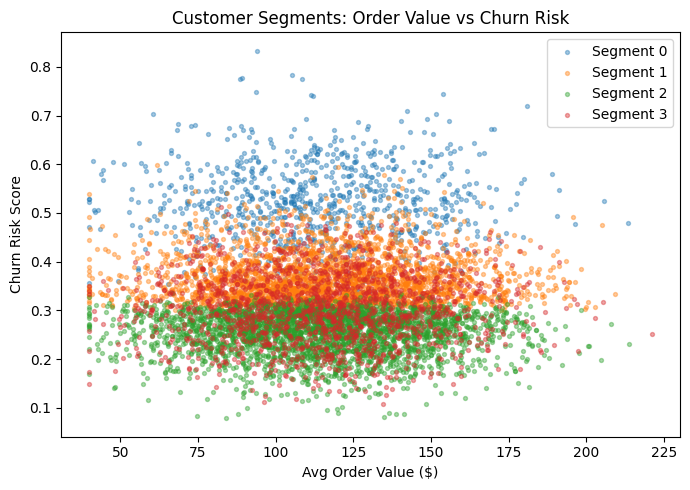

In [5]:
# Quick visual: churn risk vs order value by segment
fig, ax = plt.subplots(figsize=(7,5))
for seg in sorted(df['segment'].unique()):
    sub = df[df['segment'] == seg]
    ax.scatter(sub['avg_order_value'], sub['churn_risk_score'], s=8, alpha=0.4, label=f'Segment {seg}')
ax.set_xlabel('Avg Order Value ($)')
ax.set_ylabel('Churn Risk Score')
ax.set_title('Customer Segments: Order Value vs Churn Risk')
ax.legend()
plt.tight_layout()
plt.show()


## 4. Recommendation-response model

Simulate historical email/content campaigns and build a model predicting the likelihood a customer
responds to a given message positioning — structurally similar to prior XGBoost work used for
fixed-income pricing and portfolio risk scoring, just applied here to message response
instead of price or default risk.

Message positioning types simulated (mirroring the utility / value / premium framing):
- **A: Utility-led positioning** (practical, convenience-focused messaging)
- **B: Value-led positioning** (savings, discount-focused messaging)
- **C: Premium-led positioning** (quality, loyalty/Sizzle-Society-style messaging)


In [6]:
recommendation_types = ['A_utility', 'B_value', 'C_premium']
df['recommendation_shown'] = np.random.choice(recommendation_types, size=N)

# Simulate ground-truth response probability depending on customer + message fit
def conversion_prob(row):
    base = 0.20
    if row['recommendation_shown'] == 'A_utility':
        base += 0.60 * row['box_customization_rate']
    elif row['recommendation_shown'] == 'B_value':
        base += 0.55 * row['discount_sensitivity']
    elif row['recommendation_shown'] == 'C_premium':
        base += 0.60 * (row['tenure_months'] / 96)
    base += 0.20 * row['retail_channel_flag']
    base -= 0.40 * row['churn_risk_score']
    base += 0.15 * row['seafood_pref_share']
    return np.clip(base, 0.02, 0.95)

df['response_prob_true'] = df.apply(conversion_prob, axis=1)
df['responded'] = np.random.binomial(1, df['response_prob_true'])

print("Overall response rate:", df['responded'].mean().round(3))
df[['recommendation_shown', 'responded']].groupby('recommendation_shown').mean()


Overall response rate: 0.316


,responded
recommendation_shown,
A_utility,0.331281
B_value,0.354790
C_premium,0.263768


In [7]:
model_df = pd.get_dummies(df[features + ['recommendation_shown', 'segment', 'responded']], columns=['recommendation_shown', 'segment'])

X_model = model_df.drop(columns=['responded'])
y_model = model_df['responded']

X_train, X_test, y_train, y_test = train_test_split(X_model, y_model, test_size=0.2, random_state=42, stratify=y_model)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

clf = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, eval_metric='auc', random_state=42,
    scale_pos_weight=scale_pos_weight
)
clf.fit(X_train, y_train)

pred_proba = clf.predict_proba(X_test)[:, 1]
pred_label = clf.predict(X_test)

auc = roc_auc_score(y_test, pred_proba)
print(f"ROC-AUC: {auc:.3f}\n")
print(classification_report(y_test, pred_label))


ROC-AUC: 0.648

              precision    recall  f1-score   support

           0       0.77      0.65      0.70      1095
           1       0.43      0.58      0.50       505

    accuracy                           0.63      1600
   macro avg       0.60      0.61      0.60      1600
weighted avg       0.66      0.63      0.64      1600



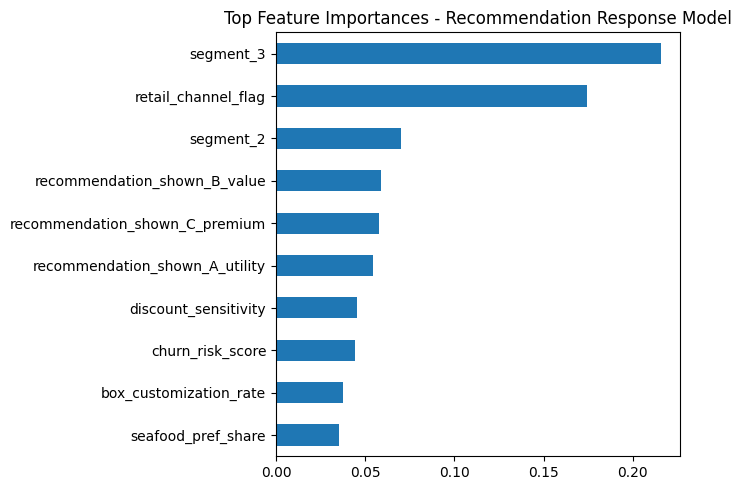

In [8]:
importances = pd.Series(clf.feature_importances_, index=X_model.columns).sort_values(ascending=False).head(10)
importances.plot(kind='barh', figsize=(7,5), title='Top Feature Importances - Recommendation Response Model')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 5. Contextual bandit simulation

Rather than statically assuming one message positioning is "best," simulate an epsilon-greedy contextual
bandit that learns, per segment, which positioning gets the best response over time — and shifts traffic
toward it while still exploring occasionally. This is the piece that maps most directly to
the "personalization / bandits" language in the role.


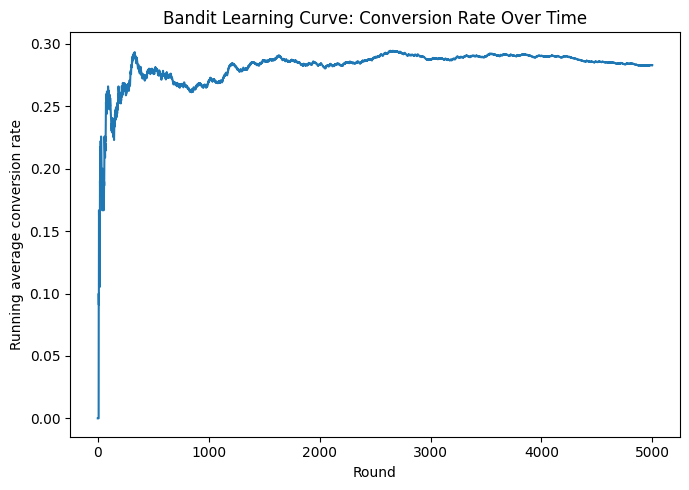

Final running conversion rate: 0.283
Static random-assignment baseline (avg true rate): 0.226


In [9]:
def true_conversion_rate(segment, recommendation):
    # Ground-truth per-segment positioning performance (unknown to the algorithm, used only to simulate outcomes)
    seg_rec_lift = {
        0: {'A_utility': 0.20, 'B_value': 0.30, 'C_premium': 0.15},
        1: {'A_utility': 0.35, 'B_value': 0.18, 'C_premium': 0.20},
        2: {'A_utility': 0.15, 'B_value': 0.20, 'C_premium': 0.32},
        3: {'A_utility': 0.22, 'B_value': 0.22, 'C_premium': 0.22},
    }
    return seg_rec_lift[segment][recommendation]

def run_bandit(n_rounds=5000, epsilon=0.1, segments=(0,1,2,3), recs=recommendation_types, seed=1):
    rng = np.random.default_rng(seed)
    # counts[segment][recommendation] and rewards[segment][recommendation]
    counts = {s: {r: 0 for r in recs} for s in segments}
    rewards = {s: {r: 0 for r in recs} for s in segments}
    cumulative_reward = 0
    history = []

    for t in range(n_rounds):
        seg = rng.choice(segments)
        if rng.random() < epsilon:
            rec = rng.choice(recs)                         # explore
        else:
            est = {r: (rewards[seg][r] / counts[seg][r] if counts[seg][r] > 0 else 0.5) for r in recs}
            rec = max(est, key=est.get)                    # exploit best-known positioning

        reward = rng.binomial(1, true_conversion_rate(seg, rec))
        counts[seg][rec] += 1
        rewards[seg][rec] += reward
        cumulative_reward += reward
        history.append(cumulative_reward / (t + 1))

    return counts, rewards, history

counts, rewards, history = run_bandit()

plt.figure(figsize=(7,5))
plt.plot(history)
plt.xlabel('Round')
plt.ylabel('Running average conversion rate')
plt.title('Bandit Learning Curve: Conversion Rate Over Time')
plt.tight_layout()
plt.show()

print(f"Final running conversion rate: {history[-1]:.3f}")
print(f"Static random-assignment baseline (avg true rate): {np.mean([true_conversion_rate(s,o) for s in (0,1,2,3) for o in recommendation_types]):.3f}")


In [10]:
learned = pd.DataFrame({
    seg: {o: round(rewards[seg][o] / counts[seg][o], 3) if counts[seg][o] > 0 else None for o in recommendation_types}
    for seg in (0,1,2,3)
}).T
learned.index.name = 'segment'
learned


,A_utility,B_value,C_premium
segment,,,
0,0.221,0.295,0.143
1,0.358,0.175,0.233
2,0.081,0.188,0.324
3,0.193,0.192,0.188


## 6. Summary — what this demonstrates

| Step | Technique | Maps to prior experience |
|---|---|---|
| Feature engineering | RFM-style + churn signal features | Feature engineering / RFE work (PNC) |
| Segmentation | KMeans clustering | Segment-driven recommendation logic (Vivma SVD engine) |
| Recommendation-response model | XGBoost classifier, ROC-AUC evaluated | XGBoost pricing/risk models (Vivma, PNC) |
| Personalization loop | Epsilon-greedy contextual bandit | New concept, applied directly to this JD's language |
| Production framing | Would deploy as scoring service, monitor drift | FastAPI/Docker deployment (PNC) |

**The core result:** the bandit simulation shows the running conversion rate climbing from a
random-assignment baseline toward the per-segment optimal positioning rate as it learns — which is
the same underlying idea as ButcherBox moving from "monolith" blanket messaging toward
individualized, behavior-driven messaging.

This isn't meant to reflect ButcherBox's actual data or results — it's a synthetic, self-directed
proof of concept built to demonstrate the same technical approach their business problem calls for.
